In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import rcParams
from datetime import datetime
%matplotlib inline
df=pd.read_csv("monthly-beer-production-in-austr.csv")
df

,Month,Monthly beer production in Australia
0,1956-01,93.2
1,1956-02,96.0
2,1956-03,95.2
3,1956-04,77.1
4,1956-05,70.9
...,...,...
471,1995-04,127.0
472,1995-05,151.0
473,1995-06,130.0
474,1995-07,119.0


Text(0, 0.5, 'Consumption in megalitres')

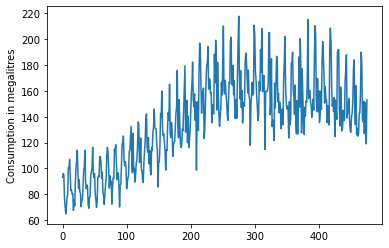

In [4]:
dateparse= lambda dates: datetime.strptime(dates, '%Y-%m')
data=pd.read_csv('monthly-beer-production-in-austr.csv', parse_dates=['Month'], date_parser=dateparse)
ts= data['Monthly beer production in Australia']
ts.plot()
plt.ylabel("Consumption in megalitres")

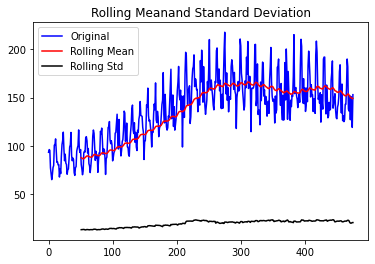

Results of Dickey Fuller Test:
Test Statistic              -2.282661
p-value                      0.177621
#Lags Used                  17.000000
No of observations used    458.000000
Critical Value (1%)         -3.444709
Critical Value (5%)         -2.867871
Critical Value (10%)        -2.570142
dtype: float64


In [5]:
#stationarity check
from statsmodels.tsa.stattools import adfuller
def test_stationarity(timeseries):
    #determing rolling statistics
    rolmean= timeseries.rolling(window=52, center=False).mean()
    rolstd= timeseries.rolling(window=52, center=False).std()
    #plot rolling statistics:
    orig=plt.plot(timeseries, color='blue', label='Original')
    mean=plt.plot(rolmean, color='Red', label='Rolling Mean')
    std=plt.plot(rolstd, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Meanand Standard Deviation')
    plt.show(block=False)
    #Perform Dickey Fuller test:
    print('Results of Dickey Fuller Test:')
    dftest=adfuller(timeseries, autolag='AIC')
    dfoutput= pd.Series(dftest[0:4], index=['Test Statistic', 'p-value','#Lags Used','No of observations used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' %key]=value
    print(dfoutput)
test_stationarity(data['Monthly beer production in Australia'])


The test statistic is more than critical value and the moving average
is not constant over time.
So, the null hypothesis of the Dickey-Fuller test cannot be rejected.
This shows that the time series is not stationary.

<AxesSubplot:>

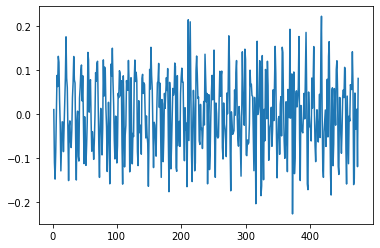

In [8]:
#Stationarize
import math
ts_log_mv_diff=pd.Series(data['Monthly beer production in Australia'].apply(lambda x:math.log(x))).rolling(window=2).mean().diff(1)
ts_log_mv_diff.dropna(inplace=True)
ts_log_mv_diff.plot()